# **INE5202 - Cálculo Numérico em Computadores**
## Relatório - Exercício Programa III

### **Alunos:** João Vitor Sutter e Pedro Henrique Gimenez
### **Linguagem escolhida:** Python 3.11

# AVISO

É possível que o código não execute, resultando no seguinte erro: "FigureCanvasAgg is non-interactive, and thus cannot be shown plt.show()". Nesse caso, basta instalar a biblioteca PyQt5.

```bash
pip install PyQt5
```

## **1. Tarefa:** Runge-Kutta de quarta ordem para aproximar as soluções do sistema de EDOs

Dadas as equações que montam o sistema SIR (Suscetíveis, Infectados e Removido), seus parâmetros e condições iniciais, podemos utilizar o método de Runge-Kutta de quarta ordem para aproximar as soluções do sistema de EDOs.

## **1.1 Programação do método**

Iniciamos o programa definindo as funções para cada condição do SIR, como pode ser observado pelo seguinte código::

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def dSdt(S, I, beta):
    return -beta * S * I

def dIdt(S, I, beta, gamma):
    return beta * S * I - gamma * I

def dRdt(I, gamma):
    return gamma * I

Em seguida, codificamos o método de Runge-Kutta de quarta ordem pela função rk4.

In [9]:
def rk4(S0, I0, R0, t0, tf, h, beta, gamma):
    """Método de Runge-Kutta de 4ª ordem para resolver o sistema de EDOs do modelo SIR."""

    t = np.arange(t0, tf + h, h)
    n = len(t)
    S, I, R = np.zeros(n), np.zeros(n), np.zeros(n)
    S[0], I[0], R[0] = S0, I0, R0


    for i in range(1, n):
        k1s = dSdt(S[i - 1], I[i - 1], beta)
        k1i = dIdt(S[i - 1], I[i - 1], beta, gamma)
        k1r = dRdt(I[i - 1], gamma)

        k2s = dSdt(S[i - 1] + (k1s * h) / 2,
                   I[i - 1] + (k1i * h) / 2,
                   beta)
        k2i = dIdt(S[i - 1] + (k1s * h) / 2,
                   I[i - 1] + (k1i * h) / 2,
                   beta, gamma)
        k2r = dRdt(I[i - 1] + (k1i * h) / 2,
                   gamma)

        k3s = dSdt(S[i - 1] + (k2s * h) / 2,
                   I[i - 1] + (k2i * h) / 2,
                   beta)
        k3i = dIdt(S[i - 1] + (k2s * h) / 2,
                   I[i - 1] + (k2i * h) / 2,
                   beta, gamma)
        k3r = dRdt(I[i - 1] + (k2i * h) / 2,
                   gamma)

        k4s = dSdt(S[i - 1] + k3s * h,
                   I[i - 1] + k3i * h,
                   beta)
        k4i = dIdt(S[i - 1] + k3s * h,
                   I[i - 1] + k3i * h,
                   beta, gamma)
        k4r = dRdt(I[i - 1] + k3i* h,
                   gamma)

        S[i] = S[i - 1] + h * (k1s + (2 * k2s) + (2 * k3s) + k4s) / 6
        I[i] = I[i - 1] + h * (k1i + (2 * k2i) + (2 * k3i) + k4i) / 6
        R[i] = R[i - 1] + h * (k1r + (2 * k2r) + (2 * k3r) + k4r) / 6

    return t, S, I, R

## **1.2 Simulações**
### **1.2.1 Simulação com os parâmetros originais**

Para realizar a simulação, descrevemos os parametros e chamamos a função rk4 para conseguirmos os pontos de Suscetíveis, Infectados e Removidos ao longo do tempo t. Repare na seguinte modificação: beta e gamma foram fornecidos em horas, e, como queremos o gráfico em dias, fizemos a conversão de 24 horas para 1 dia (ou seja, dividimos as 24 horas por 24).

In [10]:
# Parâmetros do modelo SIR. 24 foi dividido por 24 para converter de horas para dias
beta = 10 / (40 * 8 * (24 / 24))
gamma = 3 / (15 * (24 / 24))

# Simulação 1: Parâmetros originais
t, S1, I1, R1 = rk4(S0=49, I0=1, R0=0, t0=0, tf=25, h=0.1, beta=beta, gamma=gamma)

Por fim, plotamos o gráfico do sistema após ser aproximado utilizando o método de Runge-Kutta de quarta ordem.

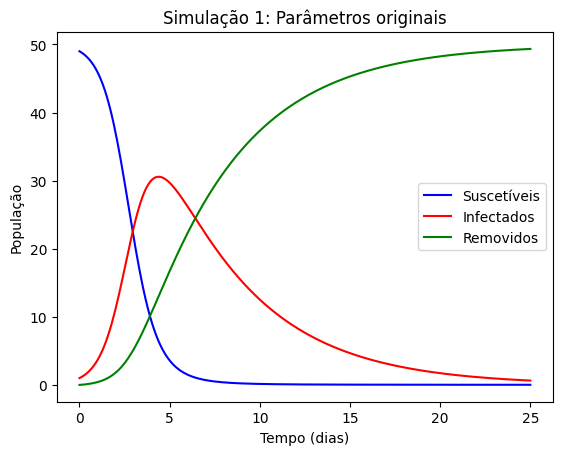

In [15]:
plt.plot(t, S1, 'b', label='Suscetíveis')
plt.plot(t, I1, 'r', label='Infectados')
plt.plot(t, R1, 'g', label='Removidos')
plt.title('Simulação 1: Parâmetros originais')
plt.xlabel('Tempo (dias)')
plt.ylabel('População')
plt.legend()
plt.show()

### **1.2.1 Simulação com os parâmetros modificados**

Para a segunda simulação, reduzimos o parâmetro beta em duas vezes, simulando uma medida de distanciamento social. Em seguida, aplicamos o método novamente e plotamos o novo gráfico.

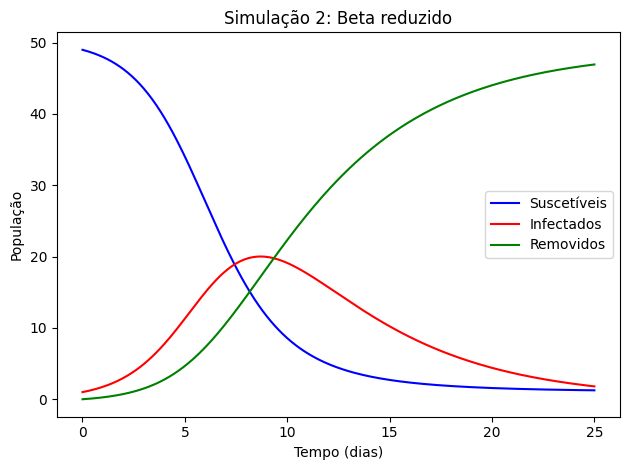

In [14]:
# Simulação 2: Beta reduzido pela metade
beta_reduced = beta / 2

t, S2, I2, R2 = rk4(S0=49, I0=1, R0=0, t0=0, tf=25, h=0.1, beta=beta_reduced, gamma=gamma)

plt.plot(t, S2, 'b', label='Suscetíveis')
plt.plot(t, I2, 'r', label='Infectados')
plt.plot(t, R2, 'g', label='Removidos')
plt.title('Simulação 2: Beta reduzido')
plt.xlabel('Tempo (dias)')
plt.ylabel('População')
plt.legend()

plt.tight_layout()
plt.show()

### **1.3 Conclusão**

Após a comparação dos dois gráficos, é possível perceber que a redução do parâmetro beta resultou em uma diminuição do pico de infectados, além de atrasar o tempo em que ele ocorre. Também é possível perceber que a curva de infectados sobe de forma mais suave no caso em que o beta é reduzido, demonstrando uma taxa de infecção menos acelerada. Consequentemente, a redução na população de suscetíveis e removidos também é mais suave no segundo caso. Portanto, no cenário proposto, as medidas de distanciamento social se mostraram eficazes na diminuição da propagação de doenças infecciosas.